# Customer Segmentation using K-Means

We have data of customers, and we want to group similar customers together

K-Means Clustering is a popular algorithm in Machine Learning used for unsupervised learning (when you don’t have labeled data).


K-Means groups data into K clusters based on similarity.

- “K” = number of clusters you want
- “Means” = average (center) of each cluster

In [1]:
import numpy as numpy
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
data = df[["Age" ,"Annual Income (k$)","Spending Score (1-100)"]]
data.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


- StandardScaler() → brings all values to similar scale
- fit_transform() → learns + applies scaling

In [7]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled[0:5] #not a DataFrame anymore. It becomes a NumPy array


array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [8]:
from sklearn.cluster import KMeans

# Elbow Method

The Elbow Method helps you choose the best value of K (number of clusters) in Machine Learning.

🔹 Idea Behind It

As you increase K:

Clusters become tighter
Error (distance from centroid) decreases

But after a certain point, improvement slows down this point is called the “elbow”

🔹 What are we measuring?

We use WCSS (Within-Cluster Sum of Squares):

WCSS=∑i=1K​∑x∈Ci​​∣∣x−μi​∣∣2

-  Lower WCSS = better clustering
-  But too many clusters = overfitting

🔹 Steps to Apply Elbow Method
1. Run K-Means for different K values (e.g., 1 to 10)
2. Compute WCSS for each K
3. Plot graph:
X-axis → K
Y-axis → WCSS
4. Find the “elbow point”

c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

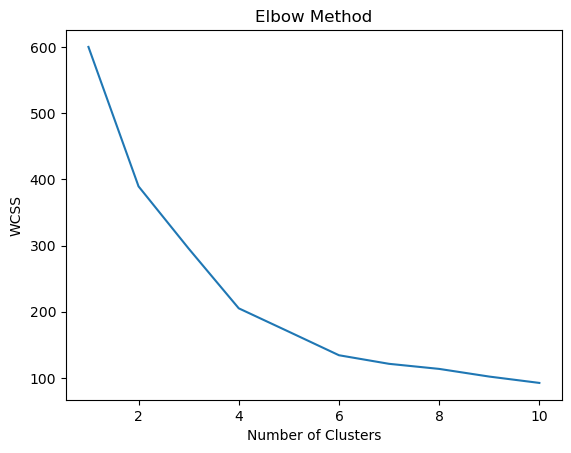

In [9]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_) # inertia_ = how tight clusters are

import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(data_scaled)

df['Cluster'] = kmeans.labels_

c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


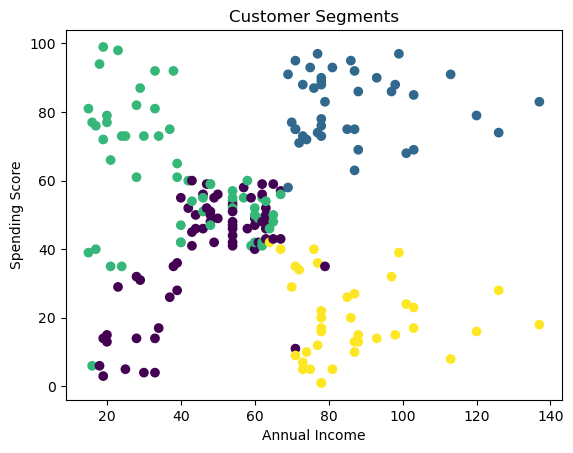

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')

plt.show()

# Key Insights from Customer Segmentation

1. Bottom-right (High income, Low spending)
Earn a lot 
Spend very little

- Careful / Saver customers
- Business idea: Target with offers to increase spending

2. Top-right (High income, High spending)
Earn a lot 
Spend a lot 

- Premium / Ideal customers 
- Business idea: Retain them, give VIP services

3. Left side (Low income, High spending)
Earn less
Spend a lot

- Impulsive / Risky customers
- Business idea: Promotions work well here

4. Middle cluster (Average income & spending)
Normal behavior

- Regular customers
- Business idea: Maintain engagement

5. Bottom-left (Low income, Low spending)
Low income
Low spending

- Low-value customers
- Business idea: Not primary focus


**Identified key customer segments such as premium, potential, and low-value groups using K-Means clustering, enabling targeted marketing strategies based on income and spending patterns.**

- Performed customer segmentation using K-Means clustering on retail dataset
- Conducted data preprocessing including feature selection and normalization
- Applied Elbow Method to determine optimal number of clusters
- Visualized customer groups based on income and spending behavior
- Derived insights to identify distinct customer segments